In [1]:
# Imports
import csv
from datasets import load_from_disk, load_dataset
import numpy as np
from ml4setk.Parsing.Code.TreeSitterQuery import TreeSitterQuery
import random
import re
from tqdm import tqdm
import os
import json
import gzip
import logging
from collections import defaultdict

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 9,  # Match acmart sigconf default
})

In [2]:
language = "Java"
tree_query = TreeSitterQuery(language=language.lower())

c:\Users\lucaw\TUProjects\RP\ML4SE-toolkit\.venv\Lib\site-packages\tree_sitter\__init__.py:36: FutureWarning: Language(path, name) is deprecated. Use Language(ptr, name) instead.
  warn("{} is deprecated. Use {} instead.".format(old, new), FutureWarning)


In [ ]:
def get_in_smell(code: str, spans: list[tuple[int, int]], smell_index: int = 0) -> tuple[str, str, str, str]:
    """
    Get the SATD span at index `smell_index` from the code, along with its prefix, suffix, and comment syntax.

    Args:
        code (str): The source code as a string.
        spans (list[tuple[int, int]]): A list of tuples where each tuple contains the start and end indices of SATD spans.
        smell_index (int): The index of the SATD span to retrieve.
    Returns:
        tuple: A tuple containing the prefix, target SATD span, suffix, and comment syntax
    Raises:
        ValueError: If the `smell_index` is out of bounds for the `spans` list.
    """
    if smell_index >= len(spans):
        raise ValueError(f"Smell index {smell_index} out of bounds for spans of length {len(spans)}")
    satd_start, satd_end = spans[smell_index]
    prefix = code[:satd_start]
    target = code[satd_start:satd_end]
    suffix = code[satd_end:]
    comment_syntax = re.match(r'//\s*|/\*+\s*', target)
    if comment_syntax:
        prefix += comment_syntax.group(0)
        target = target[comment_syntax.end():]
    return prefix, target, suffix, comment_syntax.group(0)


def get_out_smell(code: str, spans: list[tuple[int, int]], smell_index: int = 0, method_distance: int = 0) -> tuple[str, str, str]:
    """
    Get the method at `method_distance` from the SATD span at index `smell_index` in the code, along with its prefix and suffix.
    
    Args:
        code (str): The source code as a string.
        spans (list[tuple[int, int]]): A list of tuples where each tuple contains the start and end indices of SATD spans.
        smell_index (int): The index of the SATD span to retrieve.
        method_distance (int): The distance from the SATD span to the method declaration to retrieve.
    Returns:
        tuple: A tuple containing the prefix, target method declaration, and suffix.
    Raises:
        ValueError: If the `smell_index` is out of bounds for the `spans` list or if the `method_distance` exceeds the available methods.
    """
    # Include SATD + everything up to the method declaration
    if smell_index >= len(spans):
        raise ValueError(f"Smell index {smell_index} out of bounds for spans of length {len(spans)}")
    _, satd_end = spans[smell_index]
    context = code[satd_end:]
    methods = tree_query.parse(context, '(method_declaration) @method')
    if method_distance == -1 and len(methods) < 3:
        raise ValueError("Method distance -1 but less than 3 methods found")
    if method_distance < len(methods):
        method = methods[method_distance]
    else:
        raise ValueError(f"Method distance exceeds available methods, methods found: {len(methods)}, requested distance: {method_distance}")
    prefix = code[:satd_end + method[0]]
    target = method[2]
    suffix =  code[satd_end + method[1]:] # MISTAKE: should be code[satd_end + method[0] + len(method[2]):]
    return prefix, target, suffix

def remove_spans(content, spans):
    """
    Remove substrings from content based on the spans (start, end) indices.

    Args:
        content (str): The original content from which to remove spans.
        spans (list[tuple[int, int]]): A list of tuples where each tuple contains the start and end indices of substrings to remove.
    Returns:
        str: The content with the specified spans removed.
    """
    cleaned_content = content
    for start, end in sorted(spans, reverse=True):
        cleaned_content = cleaned_content[:start] + cleaned_content[end:]
    return cleaned_content


def get_no_smell_comment(code: str) -> tuple[str, str, str, str]:
    """
    Get a random comment from the code, along with its prefix, target, suffix, and comment syntax.

    Args:
        code (str): The source code as a string.
    Returns:
        tuple: A tuple containing the prefix, target comment, suffix, and comment syntax.
    Raises:
        ValueError: If no comments are found in the code.
    """
    comments = tree_query.parse(code, '(line_comment) @comment (block_comment) @comment')
    if not comments:
        raise ValueError("No comments found in the code")
    comment = random.choice(comments)
    prefix = code[:comment[0]]
    target = comment[2]
    suffix = code[comment[1]:]  # MISTAKE: should be code[-comment[1]:]
    comment_syntax = re.match(r'//\s*|/\*+\s*', target)
    if comment_syntax:
        prefix += comment_syntax.group(0)
        target = target[comment_syntax.end():]
    return prefix, target, suffix, comment_syntax.group(0)

def get_no_smell_method(code: str) -> tuple[str, str, str]:
    """
    Get a random method declaration from the code, along with its prefix and suffix.

    Args:
        code (str): The source code as a string.
    Returns:
        tuple: A tuple containing the prefix, target method declaration, and suffix.
    Raises:
        ValueError: If no methods are found in the code.
    """
    methods = tree_query.parse(code, '(method_declaration) @method')
    if not methods:
        raise ValueError("No methods found in the code")
    method = random.choice(methods)
    prefix = code[:method[0]]
    target = method[2]
    suffix = code[method[1]:]   # MISTAKE: should be code[-method[1]:]
    return prefix, target, suffix

In [2]:
def save_jsonl_gz(data, path):
    with gzip.open(path, 'wt', encoding='utf-8') as f:
        for item in data:
            json.dump(item, f)
            f.write('\n')

def load_jsonl_gz(path):
    with gzip.open(path, 'rt', encoding='utf-8') as f:
        return [json.loads(line) for line in f]

In [3]:
splits = 2
output_dir1 = "../../data/input-target/v2-ds-all-1"
output_dir2 = "../../data/input-target/v2-ds-all-2"
outputdirs = [output_dir1, output_dir2]
amount_comment = 2000
amount_method = 500
total_amount_comment = amount_comment * splits
total_amount_method = amount_method * splits

In [11]:
# Set random seed for reproducibility
random.seed(42)

In [22]:
def setup_logger(case_name: str, output_dir: str, split: int) -> logging.Logger:
    log_dir = os.path.join(output_dir, "logs")
    os.makedirs(log_dir, exist_ok=True)
    case_name = f"{case_name}_split_{split}"
    logger = logging.getLogger(case_name)
    logger.setLevel(logging.INFO)
    
    # Avoid adding multiple handlers if this function is called multiple times
    if not logger.handlers:
        handler = logging.FileHandler(os.path.join(log_dir, f"{case_name}.log"), encoding="utf-8")
        handler.setFormatter(logging.Formatter('%(asctime)s [%(levelname)s] %(message)s'))
        logger.addHandler(handler)

    return logger

In [10]:
# Load your local dataset
language = 'Java'

ds = load_dataset(
    "AISE-TUDelft/the-heap",
    f"{language}",
    split="train",
    num_proc=12
)

print(len(ds))

# Load the annotation file, optionally gzipped
annotations = []
with gzip.open("../../data/Java/satd_count_spans_annotations.jsonl.gz", "r") as f:
    for line in f:
        annotations.append(json.loads(line))

# Check length matches
assert len(ds) == len(annotations), "Length mismatch!"

def add_annotations(batch, indices):
    return {
        "satd_spans": [annotations[i]["satd_spans"] for i in indices],
        "satd_count": [annotations[i]["satd_count"] for i in indices],
    }

ds = ds.map(add_annotations, with_indices=True, batched=True, desc="Adding SATD spans and counts")


Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/67 [00:00<?, ?it/s]

5168193


In [12]:
one_smell_ds = ds.filter(lambda x: x['satd_count'] == 1)
print(len(one_smell_ds))

268658


In [23]:
random_indices = random.sample(range(len(one_smell_ds)), total_amount_comment)
random_one_smell_ds1 = one_smell_ds.select(random_indices[:amount_comment])
print(len(random_one_smell_ds1))
random_one_smell_ds2 = one_smell_ds.select(random_indices[amount_comment:])
print(len(random_one_smell_ds2))

2000
2000


In [59]:
"""
In total I have 10 cases * 2 (for causal and FiM):
1. In-smell
2. No-smell-comment
3-5. Out-smell-distance{0,1,-1}
6. No-smell-method
7-8. Multiple(-1)-out-smell-{0,-1}
9-10. Preprocessed-multiple(-1)-out-smell-{0,-1}
"""

'\nIn total I have 10 cases * 2 (for causal and FiM):\n1. In-smell\n2. No-smell-comment\n3-5. Out-smell-distance{0,1,-1}\n6. No-smell-method\n7-8. Multiple(-1)-out-smell-{0,-1}\n9-10. Preprocessed-multiple(-1)-out-smell-{0,-1}\n'

In [24]:
def create_input_target_one_smell(one_smell_ds, output_dir, split):
    cases = [
        f"in_smell_{amount_comment}",
        f"out_smell_distance(0)_{amount_method}",
        f"out_smell_distance(1)_{amount_method}",
        f"out_smell_distance(-1)_{amount_method}",
    ]
    datasets = {case: [] for case in cases}
    loggers = {name: setup_logger(name, output_dir, split) for name in cases}

    for file in tqdm(one_smell_ds, desc="Processing files"):
        # 1. In-smell
        file_name = file['file_name']
        content = file['content']
        spans = file['satd_spans']
        try:
            prefix, target, suffix, comment_syntax = get_in_smell(content, spans)
            if not target.strip():  # Validate the target
                raise ValueError("Target is empty after removing comment syntax")
            datasets[cases[0]].append({
                "file_name": file_name,
                "prefix": prefix,
                "target": target,
                "suffix": suffix,
                "comment_syntax": comment_syntax,
                "smell_index": 0
            })
        except Exception as e:
            loggers[cases[0]].warning(f"Skipping file {file_name} due to error: {e}")
            pass

    for file in tqdm(one_smell_ds.select(range(amount_method)), desc="Processing files for out-smell"):
        # 2. Out-smell distances
        file_name = file['file_name']
        content = file['content']
        spans = file['satd_spans']
        for i, dist in enumerate([0, 1, -1]):
            try:
                prefix, target, suffix = get_out_smell(content, spans, method_distance=dist)
                if not target.strip():  # Validate the target
                    raise ValueError("Target is empty")
                datasets[cases[i+1]].append({
                    "file_name": file_name,
                    "prefix": prefix,
                    "target": target,
                    "suffix": suffix,
                    "smell_index": 0,
                    "distance": dist
                })
            except Exception as e:
                loggers[cases[i+1]].warning(f"Skipping file {file_name} due to error: {e}")
                pass

    # Save everything
    os.makedirs(output_dir, exist_ok=True)
    for case, records in datasets.items():
        save_jsonl_gz(records, os.path.join(output_dir, f"{case}.jsonl.gz"))


In [25]:
for i, output_dir in enumerate(outputdirs):
    create_input_target_one_smell(random_one_smell_ds1 if i == 0 else random_one_smell_ds2, output_dir, i + 1)

Processing files for out-smell: 100%|██████████| 500/500 [00:02<00:00, 203.03it/s]


In [26]:
for output_dir in outputdirs:
    in_smell_samples = load_jsonl_gz(os.path.join(output_dir, f"in_smell_{amount_comment}.jsonl.gz"))
    len_in_smell = len(in_smell_samples)
    print(f"Number of in-smell samples: {len_in_smell}")

    for dist in [0, 1, -1]:
        out_smell_samples = load_jsonl_gz(os.path.join(output_dir, f"out_smell_distance({dist})_{amount_method}.jsonl.gz"))
        print(f"Number of out-smell samples with distance {dist}: {len(out_smell_samples)}")

Number of in-smell samples: 2000
Number of out-smell samples with distance 0: 413
Number of out-smell samples with distance 1: 334
Number of out-smell samples with distance -1: 282
Number of in-smell samples: 2000
Number of out-smell samples with distance 0: 405
Number of out-smell samples with distance 1: 337
Number of out-smell samples with distance -1: 294


In [27]:
print(in_smell_samples[0])
print(out_smell_samples[0])

{'file_name': 'HueLightHandler.java', 'prefix': '/**\n * Copyright (c) 2014,2019 Contributors to the Eclipse Foundation\n *\n * See the NOTICE file(s) distributed with this work for additional\n * information regarding copyright ownership.\n *\n * This program and the accompanying materials are made available under the\n * terms of the Eclipse Public License 2.0 which is available at\n * http://www.eclipse.org/legal/epl-2.0\n *\n * SPDX-License-Identifier: EPL-2.0\n */\npackage org.eclipse.smarthome.binding.hue.internal.handler;\n\nimport static org.eclipse.smarthome.binding.hue.internal.HueBindingConstants.*;\n\nimport java.util.AbstractMap.SimpleEntry;\nimport java.util.Arrays;\nimport java.util.List;\nimport java.util.Map;\nimport java.util.Set;\nimport java.util.concurrent.ScheduledFuture;\nimport java.util.concurrent.TimeUnit;\nimport java.util.stream.Collectors;\nimport java.util.stream.Stream;\n\nimport org.eclipse.jdt.annotation.NonNullByDefault;\nimport org.eclipse.jdt.annotat

In [18]:
zero_smell_ds = ds.filter(lambda x: x['satd_count'] == 0)
print(len(zero_smell_ds))

Filter:   0%|          | 0/5168193 [00:00<?, ? examples/s]

4736996


In [28]:
random_indices = random.sample(range(len(zero_smell_ds)), total_amount_comment)
random_zero_smell_ds1 = zero_smell_ds.select(random_indices[:amount_comment])
print(len(random_zero_smell_ds1))
random_zero_smell_ds2 = zero_smell_ds.select(random_indices[amount_comment:])
print(len(random_zero_smell_ds2))

2000
2000


In [29]:
def create_input_target_zero_smell(zero_smell_ds, output_dir, split):
    cases = [
        f"no_smell_comment_{amount_comment}",
        f"no_smell_method_{amount_method}",
    ]
    datasets = {case: [] for case in cases}
    loggers = {name: setup_logger(name, output_dir, split) for name in cases}

    for file in tqdm(zero_smell_ds, desc="Processing files"):
        # 1. No-smell-comment
        file_name = file['file_name']
        content = file['content']
        try:
            prefix, target, suffix, comment_syntax = get_no_smell_comment(content)
            if not target.strip():  # Validate the target
                raise ValueError("Target is empty after removing comment syntax")
            
            datasets[cases[0]].append({
                "file_name": file_name,
                "prefix": prefix,
                "target": target,
                "suffix": suffix,
                "comment_syntax": comment_syntax
            })
        except Exception as e:
            loggers[cases[0]].warning(f"Skipping file {file_name} due to error: {e}")
            pass

    for file in tqdm(zero_smell_ds.select(range(amount_method)), desc="Processing files for no-smell-method"):
        # 2. No-smell-method
        file_name = file['file_name']
        content = file['content']
        try:
            prefix, target, suffix = get_no_smell_method(content)
            if not target.strip():  # Validate the target
                raise ValueError("Target is empty")
            
            datasets[cases[1]].append({
                "file_name": file_name,
                "prefix": prefix,
                "target": target,
                "suffix": suffix
            })
        except Exception as e:
            loggers[cases[1]].warning(f"Skipping file {file_name} due to error: {e}")
            pass

    # Save everything
    os.makedirs(output_dir, exist_ok=True)
    for case, records in datasets.items():
        save_jsonl_gz(records, os.path.join(output_dir, f"{case}.jsonl.gz"))


In [30]:
for i, output_dir in enumerate(outputdirs):
    create_input_target_zero_smell(random_zero_smell_ds1 if i == 0 else random_zero_smell_ds2, output_dir, i + 1)

Processing files for no-smell-method: 100%|██████████| 500/500 [00:00<00:00, 648.65it/s]


In [31]:
for output_dir in outputdirs:
    # Load and print the number of samples for each case
    no_smell_comment_samples = load_jsonl_gz(os.path.join(output_dir, f"no_smell_comment_{amount_comment}.jsonl.gz"))
    print(f"Number of no-smell-comment samples: {len(no_smell_comment_samples)}")
    no_smell_method_samples = load_jsonl_gz(os.path.join(output_dir, f"no_smell_method_{amount_method}.jsonl.gz"))
    print(f"Number of no-smell-method samples: {len(no_smell_method_samples)}")

Number of no-smell-comment samples: 1543
Number of no-smell-method samples: 447
Number of no-smell-comment samples: 1573
Number of no-smell-method samples: 450


In [32]:
multiple_smell_ds = ds.filter(lambda x: x['satd_count'] > 1)
print(len(multiple_smell_ds))

Filter:   0%|          | 0/5168193 [00:00<?, ? examples/s]

162539


In [33]:
num_samples = min(total_amount_method, len(multiple_smell_ds))
random_indices = random.sample(range(len(multiple_smell_ds)), num_samples)
random_multiple_smell_ds1 = multiple_smell_ds.select(random_indices[:amount_method])
print(len(random_multiple_smell_ds1))
random_multiple_smell_ds2 = multiple_smell_ds.select(random_indices[amount_method:])
print(len(random_multiple_smell_ds2))

500
500


In [34]:
def create_input_target_multiple_smell(multiple_smell_ds, output_dir, split):
    smell_index = -1  # Default to -1 for multiple out-smell cases
    distances = [0, -1]  # Distances for out-smell
    cases = [
        f"multi({smell_index})_out_smell_distance({distances[0]})_{amount_method}",
        f"multi({smell_index})_out_smell_distance({distances[1]})_{amount_method}",
        f"preprocessed_multi({smell_index})_out_smell_distance({distances[0]})_{amount_method}",
        f"preprocessed_multi({smell_index})_out_smell_distance({distances[1]})_{amount_method}",
    ]
    datasets = {case: [] for case in cases}
    loggers = {name: setup_logger(name, output_dir, split) for name in cases}

    for file in tqdm(multiple_smell_ds, desc="Processing files"):
        # 1. Multiple out-smell distances + preprocessed
        file_name = file['file_name']
        content = file['content']
        spans = file['satd_spans']
        if len(spans) < 2:
            print(f"Skipping file {file_name} due to insufficient SATD spans")
            continue

        for i, dist in enumerate(distances):
            try:
                prefix, target, suffix = get_out_smell(content, spans, smell_index=smell_index, method_distance=dist)
                if not target.strip():  # Validate the target
                    raise ValueError("Target is empty")
                
                datasets[cases[i]].append({
                    "file_name": file_name,
                    "prefix": prefix,
                    "target": target,
                    "suffix": suffix,
                    "smell_index": smell_index,
                    "distance": dist
                })

                preprocessed_prefix = remove_spans(prefix, spans)
                datasets[cases[i + 2]].append({
                    "file_name": file_name,
                    "prefix": preprocessed_prefix,
                    "target": target,
                    "suffix": suffix,
                    "smell_index": smell_index,
                    "distance": dist
                })
            except Exception as e:
                loggers[cases[i]].warning(f"Skipping file {file_name} due to error: {e}")
                pass

    # Save everything
    os.makedirs(output_dir, exist_ok=True)
    for case, records in datasets.items():
        save_jsonl_gz(records, os.path.join(output_dir, f"{case}.jsonl.gz"))

In [35]:
for i, output_dir in enumerate(outputdirs):
    print(f"Processing split {i+1} for one smell dataset")
    create_input_target_multiple_smell(random_multiple_smell_ds1 if i == 0 else random_multiple_smell_ds2, output_dir, i + 1)

Processing split 1 for one smell dataset


Processing files: 100%|██████████| 500/500 [00:04<00:00, 124.10it/s]


Processing split 2 for one smell dataset


Processing files: 100%|██████████| 500/500 [00:05<00:00, 98.58it/s] 


In [36]:
for output_dir in outputdirs:
    for dist in [0, -1]:
        multi_smell_smaples = load_jsonl_gz(os.path.join(output_dir, f"multi(-1)_out_smell_distance({dist})_{amount_method}.jsonl.gz"))
        print(f"Number of multi-smell samples with distance {dist}: {len(multi_smell_smaples)}")

    for dist in [0, -1]:
        preprocessed_multi_smell_smaples = load_jsonl_gz(os.path.join(output_dir, f"preprocessed_multi(-1)_out_smell_distance({dist})_{amount_method}.jsonl.gz"))
        print(f"Number of preprocessed multi-smell samples with distance {dist}: {len(preprocessed_multi_smell_smaples)}")

Number of multi-smell samples with distance 0: 398
Number of multi-smell samples with distance -1: 290
Number of preprocessed multi-smell samples with distance 0: 398
Number of preprocessed multi-smell samples with distance -1: 290
Number of multi-smell samples with distance 0: 405
Number of multi-smell samples with distance -1: 314
Number of preprocessed multi-smell samples with distance 0: 405
Number of preprocessed multi-smell samples with distance -1: 314


In [3]:
# [case] = list of target lengths
lengths_per_case = defaultdict(list)
single_line_methods = defaultdict(list)

amount_comment = 2000
amount_method = 500
cases = [
    f"in_smell_{amount_comment}",
    f"no_smell_comment_{amount_comment}",
    f"out_smell_distance(0)_{amount_method}",
    f"out_smell_distance(1)_{amount_method}",
    f"out_smell_distance(-1)_{amount_method}",
    f"no_smell_method_{amount_method}",
    f"multi(-1)_out_smell_distance(0)_{amount_method}",
    f"preprocessed_multi(-1)_out_smell_distance(0)_{amount_method}",
    f"multi(-1)_out_smell_distance(-1)_{amount_method}",
    f"preprocessed_multi(-1)_out_smell_distance(-1)_{amount_method}"
]

output_dir1 = "../../data/input-target/v2-ds-all-1"
output_dir2 = "../../data/input-target/v2-ds-all-2"
outputdirs = [output_dir1, output_dir2]

def load_jsonl_gz(path):
    with gzip.open(path, 'rt', encoding='utf-8') as f:
        return [json.loads(line) for line in f]
    
for output_dir in outputdirs:
    for case in cases:
        samples = load_jsonl_gz(os.path.join(output_dir, f"{case}.jsonl.gz"))
        lengths = [len(sample['target']) for sample in samples]
        lengths_per_case[case].extend(lengths)

        for sample in samples:
            if 'target' in sample and len(sample['target'].splitlines()) <= 3 :
                single_line_methods[case].append(sample)

# Print the average lengths for each case
for case, lengths in lengths_per_case.items():
    if lengths:
        avg_length = np.mean(lengths)
        std_length = np.std(lengths)
        print(f"Average length for {case}: {avg_length:.2f} ± {std_length:.2f}")
    else:
        print(f"No samples found for {case}")

print("")

proportions = []
# Print the number of single-line methods for each case
for case, methods in single_line_methods.items():
    proportion = len(methods) / len(lengths_per_case[case]) if lengths_per_case[case] else 0
    proportions.append(proportion)
    print(proportion)
    print(f"proportion of short-line l<=3 methods for {case}: {proportion:.2%}")

Average length for in_smell_2000: 229.99 ± 3963.15
Average length for no_smell_comment_2000: 255.33 ± 377.89
Average length for out_smell_distance(0)_500: 574.28 ± 1299.29
Average length for out_smell_distance(1)_500: 552.93 ± 1109.21
Average length for out_smell_distance(-1)_500: 424.15 ± 731.08
Average length for no_smell_method_500: 426.39 ± 891.20
Average length for multi(-1)_out_smell_distance(0)_500: 820.92 ± 2988.17
Average length for preprocessed_multi(-1)_out_smell_distance(0)_500: 820.92 ± 2988.17
Average length for multi(-1)_out_smell_distance(-1)_500: 496.75 ± 2126.86
Average length for preprocessed_multi(-1)_out_smell_distance(-1)_500: 496.75 ± 2126.86

0.843
proportion of short-line l<=3 methods for in_smell_2000: 84.30%
0.5311296534017972
proportion of short-line l<=3 methods for no_smell_comment_2000: 53.11%
0.21515892420537897
proportion of short-line l<=3 methods for out_smell_distance(0)_500: 21.52%
0.23397913561847988
proportion of short-line l<=3 methods for out_sm

In [4]:
label_cases = [
    "in-smell", "no-smell-comment", 
    "out-smell(0)", "out-smell(1)", "out-smell(-1)", "no-smell",
    "multi-out(0)", "prep-multi-out(0)", "multi-out(-1)", "prep-multi-out(-1)"
]

colors = ['#E69F00', '#56B4E9', '#009E73', '#D55E00']  # orange, sky blue, green, red

print("getting lengths and proportions")
lengths = [lengths_per_case[case] for case in cases]
print(len(lengths))
print(len(proportions))

getting lengths and proportions
10
10


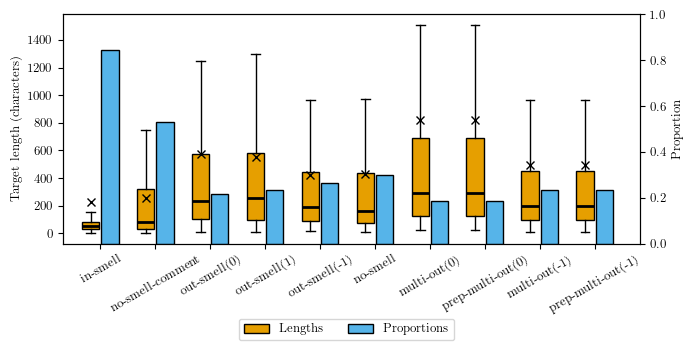

In [6]:
# X positions
x = np.arange(len(cases))
width = 0.35  # Half width for each pair

fig, ax1 = plt.subplots(figsize=(7, 3.5))
ax2 = ax1.twinx()

# Boxplots (on left of each x-tick)
box_positions = x - width / 2
for i, pos in enumerate(box_positions):
    bp = ax1.boxplot(lengths[i], positions=[pos], widths=width*0.9,
                     patch_artist=True, showmeans=True, showfliers=False,
                     meanprops=dict(marker='x', markeredgecolor='black', markerfacecolor='black'),
                     medianprops=dict(color='black', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(colors[0])

# Bars (on right of each x-tick)
bar_positions = x + width / 2
bars = ax2.bar(bar_positions, proportions, width=width*0.9, color=colors[1], edgecolor='black')

# Axes settings
ax1.set_ylabel("Target length (characters)")
ax2.set_ylabel("Proportion")
ax2.set_ylim(0, 1)

# X-axis labels centered between boxplot and bar
ax1.set_xticks(x)
ax1.set_xticklabels(label_cases, rotation=30)

legend_names = ['Lengths', 'Proportions']
handles = [mpl.patches.Patch(facecolor=colors[i % len(colors)], edgecolor='black') for i in range(len(legend_names))]
        
fig.legend(handles, legend_names, loc='lower center', ncol=len(legend_names), bbox_to_anchor=(0.5, -0.05), frameon=True)

# Title and layout
# fig.suptitle("Lengths (boxplots) and Proportions (bars) per Case", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("lengths_proportions_per_case.png", bbox_inches='tight', format='png', dpi=300)
